<a href="https://colab.research.google.com/github/stephentangzizhong/Neuroinformatics-Workshop-Code/blob/main/NEUR0019_Final_Exam_2025_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NEUR0019 EXAM: Linear shift vs circular shift

**Please add your candidate number here**: XYKX9

In this worksheet we will use the linear shift method to evaluate the statistical significance of using brain activity recorded in a mouse to predict simultaneously-recorded video motion energy (how much the mouse is moving), and
simultaneous bitcoin prices.


**Instructions**

- Do not use AI tools for this assessment
- Go through the notebook top-to-bottom.  Run all cells that contain code
- Answer all QUESTIONs in the cells below
- Write and execute code where requested

In [ ]:
# This cell downloads the data (zip) unzips and loads it
import numpy as np
import matplotlib.pyplot as plt
import pathlib, zipfile, urllib.request
np.random.seed(0)

ZIP_URL = "https://github.com/kdharris101/NeuralCodingClass/raw/main/data/0cf6d255_data_crypto.zip"

out_dir = pathlib.Path("shift_exam_data")
out_dir.mkdir(exist_ok=True)

zip_path = out_dir / "data.zip"
urllib.request.urlretrieve(ZIP_URL, zip_path)

# Unzip
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(out_dir)



In [ ]:
# Load the data The data are arrays sampled at 5s
# X: size (time, neurons) firing rates (spikes/s)
# y_motion: (time,) video motion energy
# y_crypto: (time,) crypto price

X = np.load("shift_exam_data/X_5s.npy")
y_motion = np.load("shift_exam_data/y_motion_5s.npy")
y_crypto = np.load("shift_exam_data/y_crypto_5s.npy")

T, N = X.shape
assert y_motion.shape == (T,)
assert y_crypto.shape == (T,)

print("X:", X.shape, "y_motion:", y_motion.shape, "y_crypto:", y_crypto.shape)



X: (808, 768) y_motion: (808,) y_crypto: (808,)


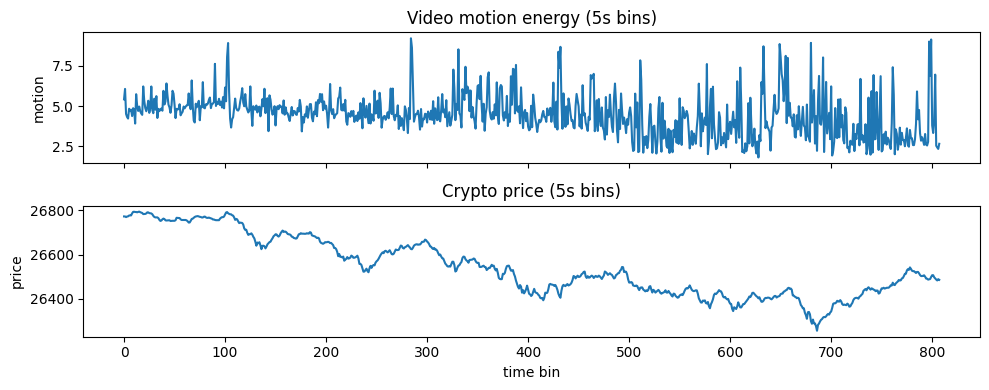

In [ ]:
# Make quick sanity plots of the two targets
fig, ax = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
ax[0].plot(y_motion)
ax[0].set_title("Video motion energy (5s bins)")
ax[0].set_ylabel("motion")

ax[1].plot(y_crypto)
ax[1].set_title("Crypto price (5s bins)")
ax[1].set_ylabel("price")
ax[1].set_xlabel("time bin")

plt.tight_layout()



In [ ]:
# Define functions to compute ridge regression, and to measure predictability as R^2

def ridge_fit_predict(X, y, lam=1e3):
    """Fit ridge regression (no intercept; we mean-center X and y) and return centered y and predictions."""
    X = np.asarray(X)
    y = np.asarray(y)

    Xc = X - X.mean(axis=0, keepdims=True)
    yc = y - y.mean()

    N = Xc.shape[1]
    beta = np.linalg.solve(Xc.T @ Xc + lam * np.eye(N), Xc.T @ yc)
    yhat = Xc @ beta
    return yc, yhat


def r2(yc, yhat):
    """R^2 on mean-centered y."""
    ssr = np.sum((yc - yhat) ** 2)
    sst = np.sum(yc ** 2)
    return 1.0 - ssr / sst


# Part 1 — Linear shift test (motion)

In the lectures, we used a **linear shift test**: we shift the target *without wrap-around*, and compare the score at shift 0 to the null distribution of scores at nonzero shifts.

We keep a **central window** of neural activity fixed, and align it to shifted windows of the target.


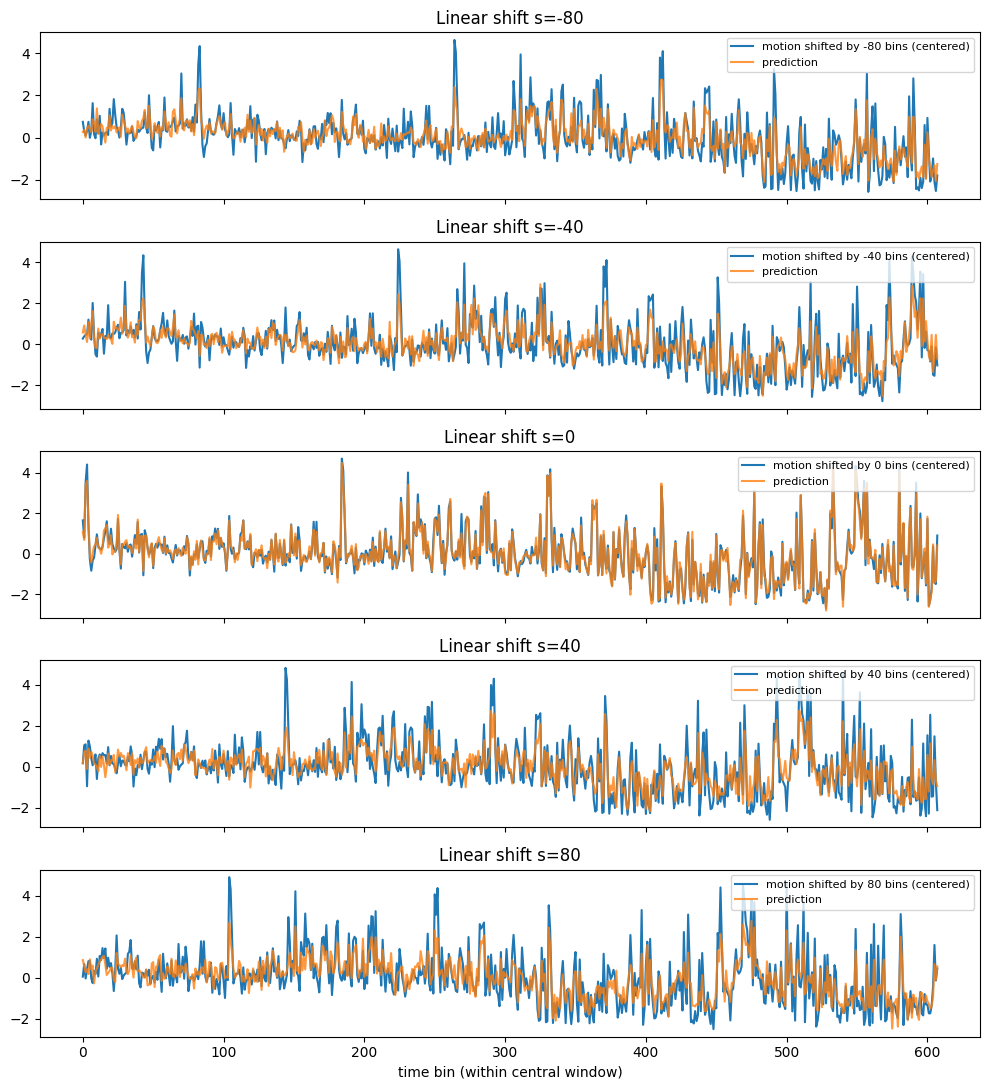

In [ ]:
# First let's plot some shifted versions of motion (linear shifts) and predictions
example_shifts = [-80, -40, 0, 40, 80]

# Shift grid (in 5s bins)
margin = 100
shifts = np.arange(-margin, margin+1)  # 201 shifts
i0 = margin
i1 = T - margin
Xc = X[i0:i1]

fig, axes = plt.subplots(len(example_shifts), 1, figsize=(10, 2.2*len(example_shifts)), sharex=True)
for k, s in enumerate(example_shifts):
    # Align central X window to a shifted y window WITHOUT wrap-around
    y_s = y_motion[i0+s : i1+s]
    yc, yhat = ridge_fit_predict(Xc, y_s)
    axes[k].plot(yc, label=f"motion shifted by {s} bins (centered)")
    axes[k].plot(yhat, label="prediction", alpha=0.8)
    axes[k].set_title(f"Linear shift s={s}")
    axes[k].legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("time bin (within central window)")
plt.tight_layout()



**QUESTION 1**

Describe what you see in these examples of shifted motion energy and its prediction by ridge regression from neural activity.   Does it look like there is going to be a significant correlation?

**Answer:** In these examples, for the motion energy, the line is just shifted to the left or right without changing the shape. For the prediction by ridge regression, when there's no shift in motion energy, it looks like almost the same as the motion energy graph (highly correlated). But for the other shifts, it looks somewhat consistent with the bigger trend of motion energy, but not so much for the fine details (much less correlated).  
Yes, it looks like there's going to be a significant correlation.

Central window bins: 100 to 708 (length 608 )
Linear shift test (motion) p= 0.004975124378109453


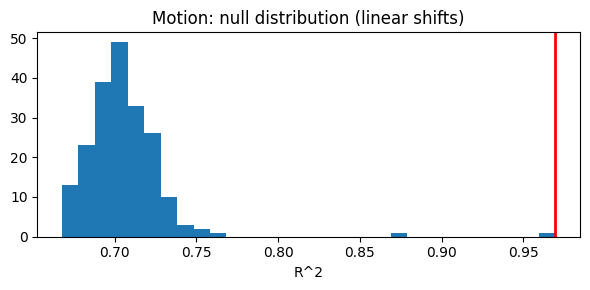

In [ ]:
# Linear shift significance test for motion (provided)
print("Central window bins:", i0, "to", i1, "(length", i1-i0, ")")

Vs_motion_lin = []
for s in shifts:
    y_s = y_motion[i0+s : i1+s]
    yc, yhat = ridge_fit_predict(Xc, y_s)
    Vs_motion_lin.append(r2(yc, yhat))

Vs_motion_lin = np.array(Vs_motion_lin)
V0_motion_lin = Vs_motion_lin[shifts == 0]
p_motion_lin = (np.sum(Vs_motion_lin >= V0_motion_lin)) / (len(Vs_motion_lin))

print("Linear shift test (motion) p=", p_motion_lin)

plt.figure(figsize=(6, 3))
plt.hist(Vs_motion_lin, bins=30)
plt.axvline(V0_motion_lin, linewidth=2, color='r')
plt.title("Motion: null distribution (linear shifts)")
plt.xlabel("R^2")
plt.tight_layout()


**QUESTION 2**

Run the code cell above. What does this plot tell us?

**Answer:** The plot tells us that under the null hypothesis that the neural activity does not correlate to motion energy, the probability of seeing a R^2 predictability (how well our ridge regression from neural activity predicts motion energy) as extreme as our observation is at p= 0.004975124378109453, which means the correlation with non-shifted motion energy is very likely to be different from that with the shifted. The cell is likely to code for motion energy.

**QUESTION 3 (LEVEL 7 ONLY)**

a. Why is there no "+1" term in the calculation of significance?

b. There are two definitions of significance for the linear shift test - approximate and conservative.  Which one is this?

# Part 2 — Linear shift test (crypto)

Now repeat the *same* analysis, but using the crypto target instead of motion.

Modify the code above to:
1. Plot the central portion of crypto and its prediction (shift 0).
2. Plot a few shifted versions (same `example_shifts`) and their predictions.
3. Compute the linear-shift p-value for crypto.


Central window bins: 100 to 708 (length 608 )
Linear shift test (crypto) p= 0.5124378109452736


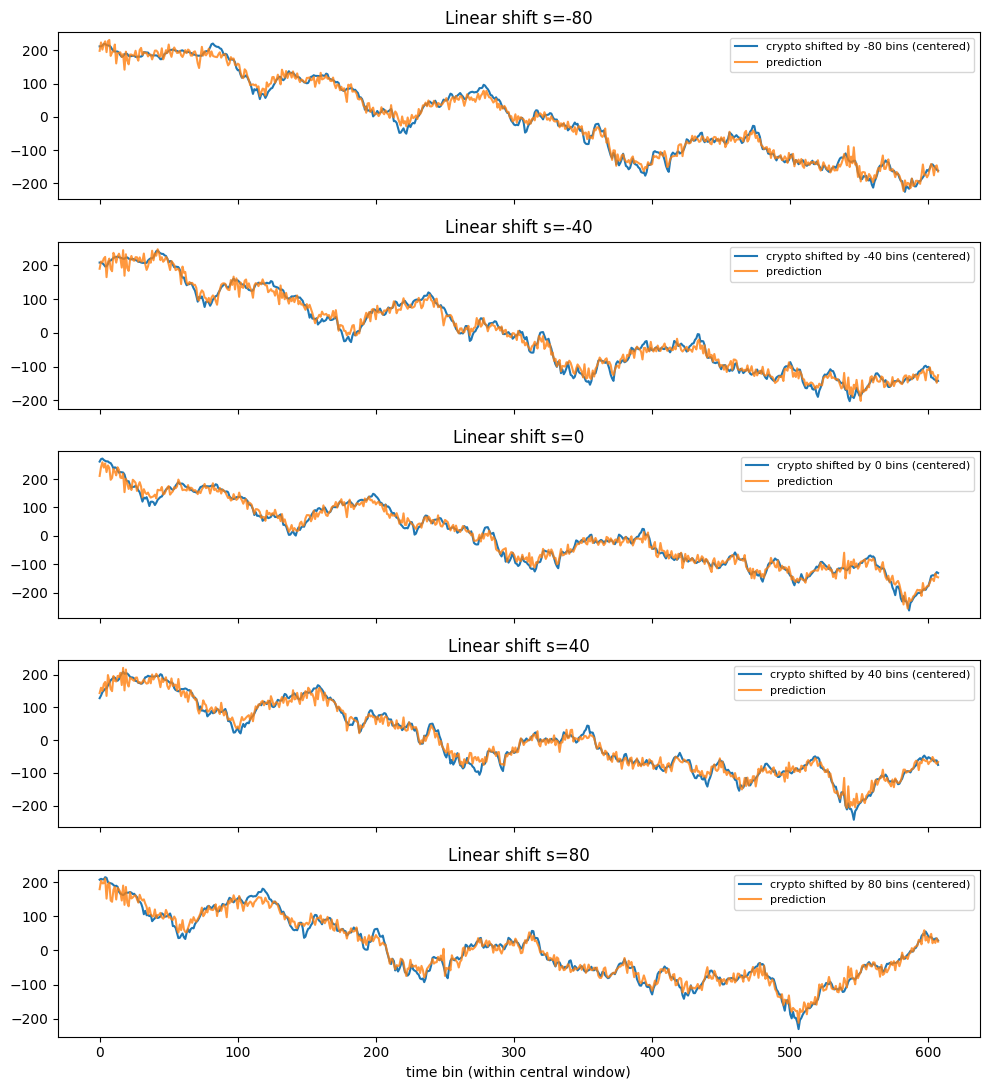

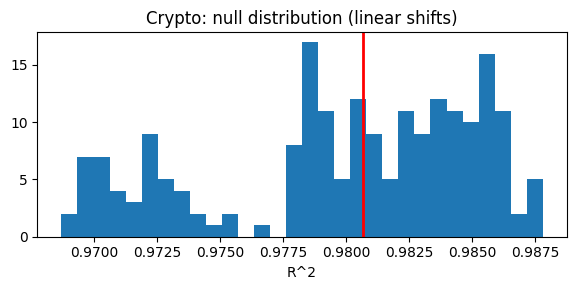

In [ ]:
# Write code here
# First let's plot some shifted versions of crypto (linear shifts) and predictions
example_shifts = [-80, -40, 0, 40, 80]

# Shift grid (in 5s bins)
margin = 100
shifts = np.arange(-margin, margin+1)  # 201 shifts
i0 = margin
i1 = T - margin
Xc = X[i0:i1]

fig, axes = plt.subplots(len(example_shifts), 1, figsize=(10, 2.2*len(example_shifts)), sharex=True)
for k, s in enumerate(example_shifts):
    # Align central X window to a shifted y window WITHOUT wrap-around
    y_s = y_crypto[i0+s : i1+s]
    yc, yhat = ridge_fit_predict(Xc, y_s)
    axes[k].plot(yc, label=f"crypto shifted by {s} bins (centered)")
    axes[k].plot(yhat, label="prediction", alpha=0.8)
    axes[k].set_title(f"Linear shift s={s}")
    axes[k].legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("time bin (within central window)")
plt.tight_layout()

# Linear shift significance test for crypto (provided)
print("Central window bins:", i0, "to", i1, "(length", i1-i0, ")")

Vs_crypto_lin = []
for s in shifts:
    y_s = y_crypto[i0+s : i1+s]
    yc, yhat = ridge_fit_predict(Xc, y_s)
    Vs_crypto_lin.append(r2(yc, yhat))

Vs_crypto_lin = np.array(Vs_crypto_lin)
V0_crypto_lin = Vs_crypto_lin[shifts == 0]
p_crypto_lin = (np.sum(Vs_crypto_lin >= V0_crypto_lin)) / (len(Vs_crypto_lin))

print("Linear shift test (crypto) p=", p_crypto_lin)

plt.figure(figsize=(6, 3))
plt.hist(Vs_crypto_lin, bins=30)
plt.axvline(V0_crypto_lin, linewidth=2, color='r')
plt.title("Crypto: null distribution (linear shifts)")
plt.xlabel("R^2")
plt.tight_layout()

**QUESTION 4**

What do these plots and analyses tell us?

**Answer:** The crypto-prediction line graphs shows that the correlations are high for both shifted and nonshifted crypto prices. The significance test tells us nothing because it fails to reject the null hypothesis. Under the null hypothesis that the neural activity does not correlate to crypto prices, the probability of seeing a R^2 predictability (how well our ridge regression from neural activity predicts crypto prices) as extreme as our observation is at p= 0.5124378109452736, which means the correlation with non-shifted crypto prices is not likely to be different from that with the shifted. The seemingly nice correlation between neural activity and crypto prices is likely due to both their correlations with time.

# Part 3 — Circular shift test (motion)

A **circular shift** wraps the end of the recording around to the beginning.

We will use `np.roll(y, s)` to circularly shift an array by `s` bins.


In [ ]:
# Example: np.roll wraps around
a = np.arange(10)
print("a         =", a)
print("roll +3   =", np.roll(a, 3))
print("roll -3   =", np.roll(a, -3))


a         = [0 1 2 3 4 5 6 7 8 9]
roll +3   = [7 8 9 0 1 2 3 4 5 6]
roll -3   = [3 4 5 6 7 8 9 0 1 2]


Circular shift test (motion) p= 0.01


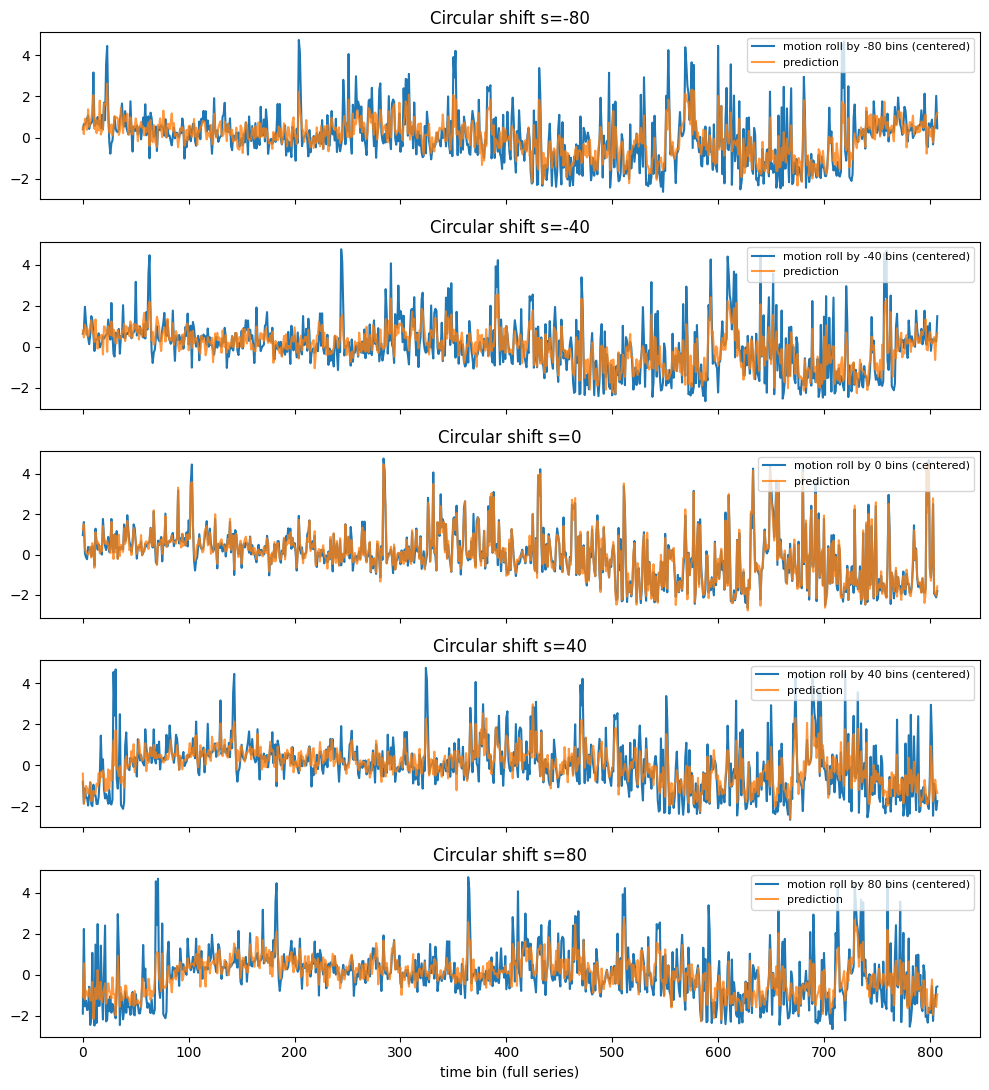

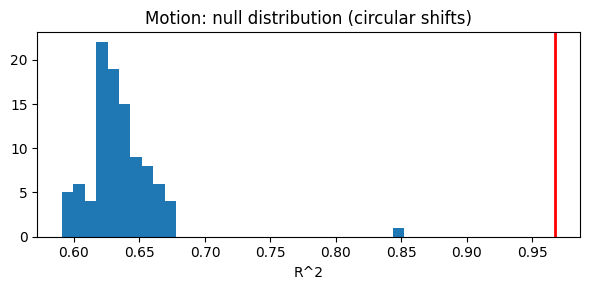

In [ ]:
# Plot circularly shifted motion and predictions

fig, axes = plt.subplots(len(example_shifts), 1, figsize=(10, 2.2*len(example_shifts)), sharex=True)
for k, s in enumerate(example_shifts):
    y_s = np.roll(y_motion, s)
    yc, yhat = ridge_fit_predict(X, y_s)
    axes[k].plot(yc, label=f"motion roll by {s} bins (centered)")
    axes[k].plot(yhat, label="prediction", alpha=0.8)
    axes[k].set_title(f"Circular shift s={s}")
    axes[k].legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("time bin (full series)")
plt.tight_layout()

# Circular shift significance test for motion
yc0, yhat0 = ridge_fit_predict(X, y_motion)
V0_motion_circ = r2(yc0, yhat0)

# Pick 99 random shifts from the whole time series length
circ_shifts = np.random.choice(np.arange(T), size=99, replace=False)

Vs_motion_circ = []
for s in circ_shifts:
    y_s = np.roll(y_motion, s)
    yc, yhat = ridge_fit_predict(X, y_s)
    Vs_motion_circ.append(r2(yc, yhat))

Vs_motion_circ = np.array(Vs_motion_circ)
p_motion_circ = (1 + np.sum(Vs_motion_circ >= V0_motion_circ)) / (1 + len(Vs_motion_circ))

print("Circular shift test (motion) p=", p_motion_circ)

plt.figure(figsize=(6, 3))
plt.hist(Vs_motion_circ, bins=30)
plt.axvline(V0_motion_circ, linewidth=2, color='r')
plt.title("Motion: null distribution (circular shifts)")
plt.xlabel("R^2")
plt.tight_layout()

**QUESTION 5**

What do these plots tell us?

**Answer:** They tell us that the neuron is likely to code for motion energy. The overall results from linear shift and circular shift methods are consistent for motion energy.  
Like the linear shift plots, the circular shift plots also show that the prediction by ridge regression from neural activity is highly correlated with the non-shifted motion energy, but not as much for the shifted motion energy.  
For the significance test, under the null hypothesis that the neural activity does not correlate to motion energy, the probability of seeing a R^2 predictability (how well our ridge regression from neural activity predicts motion energy) as extreme as our observation is at p= 0.01, which means the correlation with non-shifted motion energy is very likely to be different from that with the shifted.  

**QUESTION 6 (LEVEL 7 ONLY)**

Why is there now a "+1" term in the significance formula?

# Part 4 — Circular shift test (crypto)

Now repeat the circular-shift analysis for crypto.

Modify the code above to:
1. Plot circularly shifted crypto and its predictions (same `example_shifts`).
2. Compute the circular-shift p-value for crypto (`p_crypto_circ`).
3. Make a histogram of the null distribution with a vertical line for $V_0$.


**WARNING** Don't be surprised if you *do* see significance for crypto prediction

Circular shift test (crypto) p= 0.01


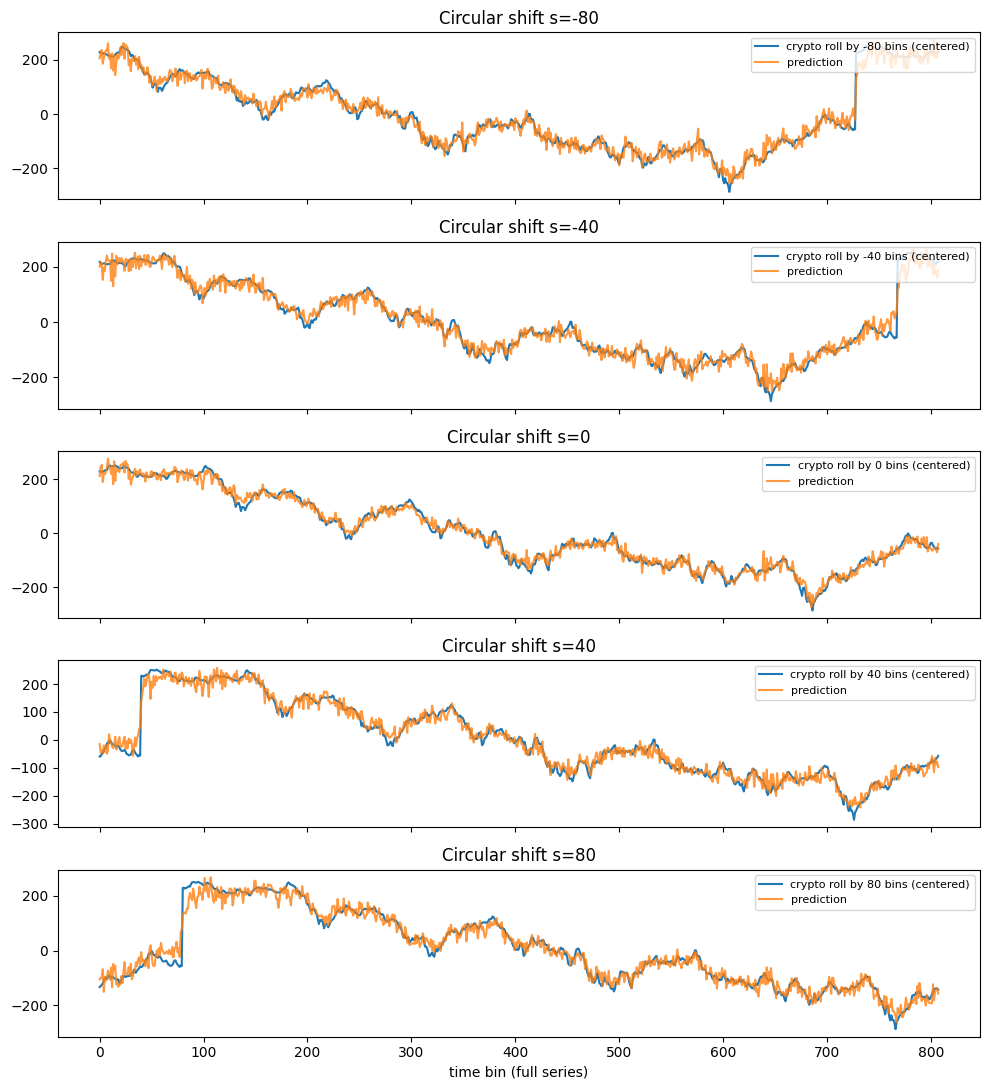

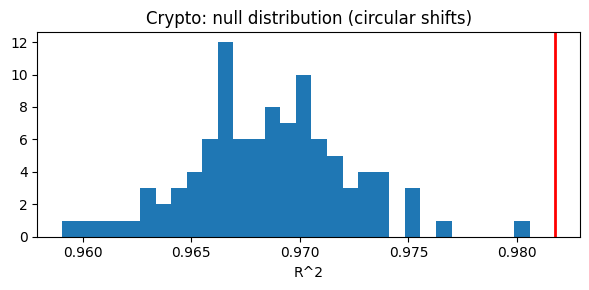

In [ ]:
# Write code here
# Plot circularly shifted crypto and predictions

fig, axes = plt.subplots(len(example_shifts), 1, figsize=(10, 2.2*len(example_shifts)), sharex=True)
for k, s in enumerate(example_shifts):
    y_s = np.roll(y_crypto, s)
    yc, yhat = ridge_fit_predict(X, y_s)
    axes[k].plot(yc, label=f"crypto roll by {s} bins (centered)")
    axes[k].plot(yhat, label="prediction", alpha=0.8)
    axes[k].set_title(f"Circular shift s={s}")
    axes[k].legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("time bin (full series)")
plt.tight_layout()

# Circular shift significance test for crypto
yc0, yhat0 = ridge_fit_predict(X, y_crypto)
V0_crypto_circ = r2(yc0, yhat0)

# Pick 99 random shifts from the whole time series length
circ_shifts = np.random.choice(np.arange(T), size=99, replace=False)

Vs_crypto_circ = []
for s in circ_shifts:
    y_s = np.roll(y_crypto, s)
    yc, yhat = ridge_fit_predict(X, y_s)
    Vs_crypto_circ.append(r2(yc, yhat))

Vs_crypto_circ = np.array(Vs_crypto_circ)
p_crypto_circ = (1 + np.sum(Vs_crypto_circ >= V0_crypto_circ)) / (1 + len(Vs_crypto_circ))

print("Circular shift test (crypto) p=", p_crypto_circ)

plt.figure(figsize=(6, 3))
plt.hist(Vs_crypto_circ, bins=30)
plt.axvline(V0_crypto_circ, linewidth=2, color='r')
plt.title("Crypto: null distribution (circular shifts)")
plt.xlabel("R^2")
plt.tight_layout()

**QUESTION 7**

Why was prediction of the non-shifted crypto prices more accurate than prediction of the circularly-shifted crypto prices?

**Answer:** The crypto price and the neural activity seem to be correlated with each other only because they both depend smoothly on time.  
In linear shift method, even if you shift the crypto prices, the two still depend smoothly on time. Thus, they still look like they're correlated, resulting in a large p-value.  
In circular shift method, however, when the crypto prices near the end of the central window are moved to the start (or vice versa), the smooth dependence on time is broken. Therefore the shifted would look less correlated than the non-shifted, resulting in a small p-value.

 **QUESTION 8 (LEVEL 7 ONLY)**

 What is the null hypothesis that the circular shift test is testing?  Why is it false even though there is no correlation between brain activity and crypto prices?